In [1]:
from data_analysis import Analyzer, DataPreprocessor
import pandas as pd

## Analyse du jeu de données - pas de preprocessing

In [2]:
df = pd.read_csv("RH_dataset.csv", sep=';', encoding='utf-8-sig')
analysis_RH_raw=Analyzer(df)

Dataset ready: 23857 rows and 14 columns.


In [3]:
analysis_RH_raw.df.columns

Index(['Famille d'emploi', 'Dernière promotion (mois)',
       'Dernière augmentation (mois)', 'Début de contrat (années)',
       'Ancienneté groupe (années)', 'Etablissement', 'Âge (années)', 'Parent',
       'Niveau hiérarchique', 'Salaire (Euros)', 'Statut marital', 'Véhicule',
       'matricule', 'label'],
      dtype='object')

In [4]:
analysis_RH_raw.get_inventory()

,Column,Type,Cardinality,Missing,Range/Examples
0,Famille d'emploi,object,8,0,"[Production, Commercial/Business, Etudes & Tec..."
1,Dernière promotion (mois),float64,7670,0,N/A (Numeric)
2,Dernière augmentation (mois),float64,2934,0,N/A (Numeric)
3,Début de contrat (années),float64,2433,0,N/A (Numeric)
4,Ancienneté groupe (années),float64,3660,0,N/A (Numeric)
5,Etablissement,int64,35,0,N/A (Numeric)
6,Âge (années),int64,74,0,N/A (Numeric)
7,Parent,int64,2,0,N/A (Numeric)
8,Niveau hiérarchique,int64,4,0,N/A (Numeric)
9,Salaire (Euros),int64,4901,0,N/A (Numeric)


On plote les distributions sur toutes les colonnes numériques.

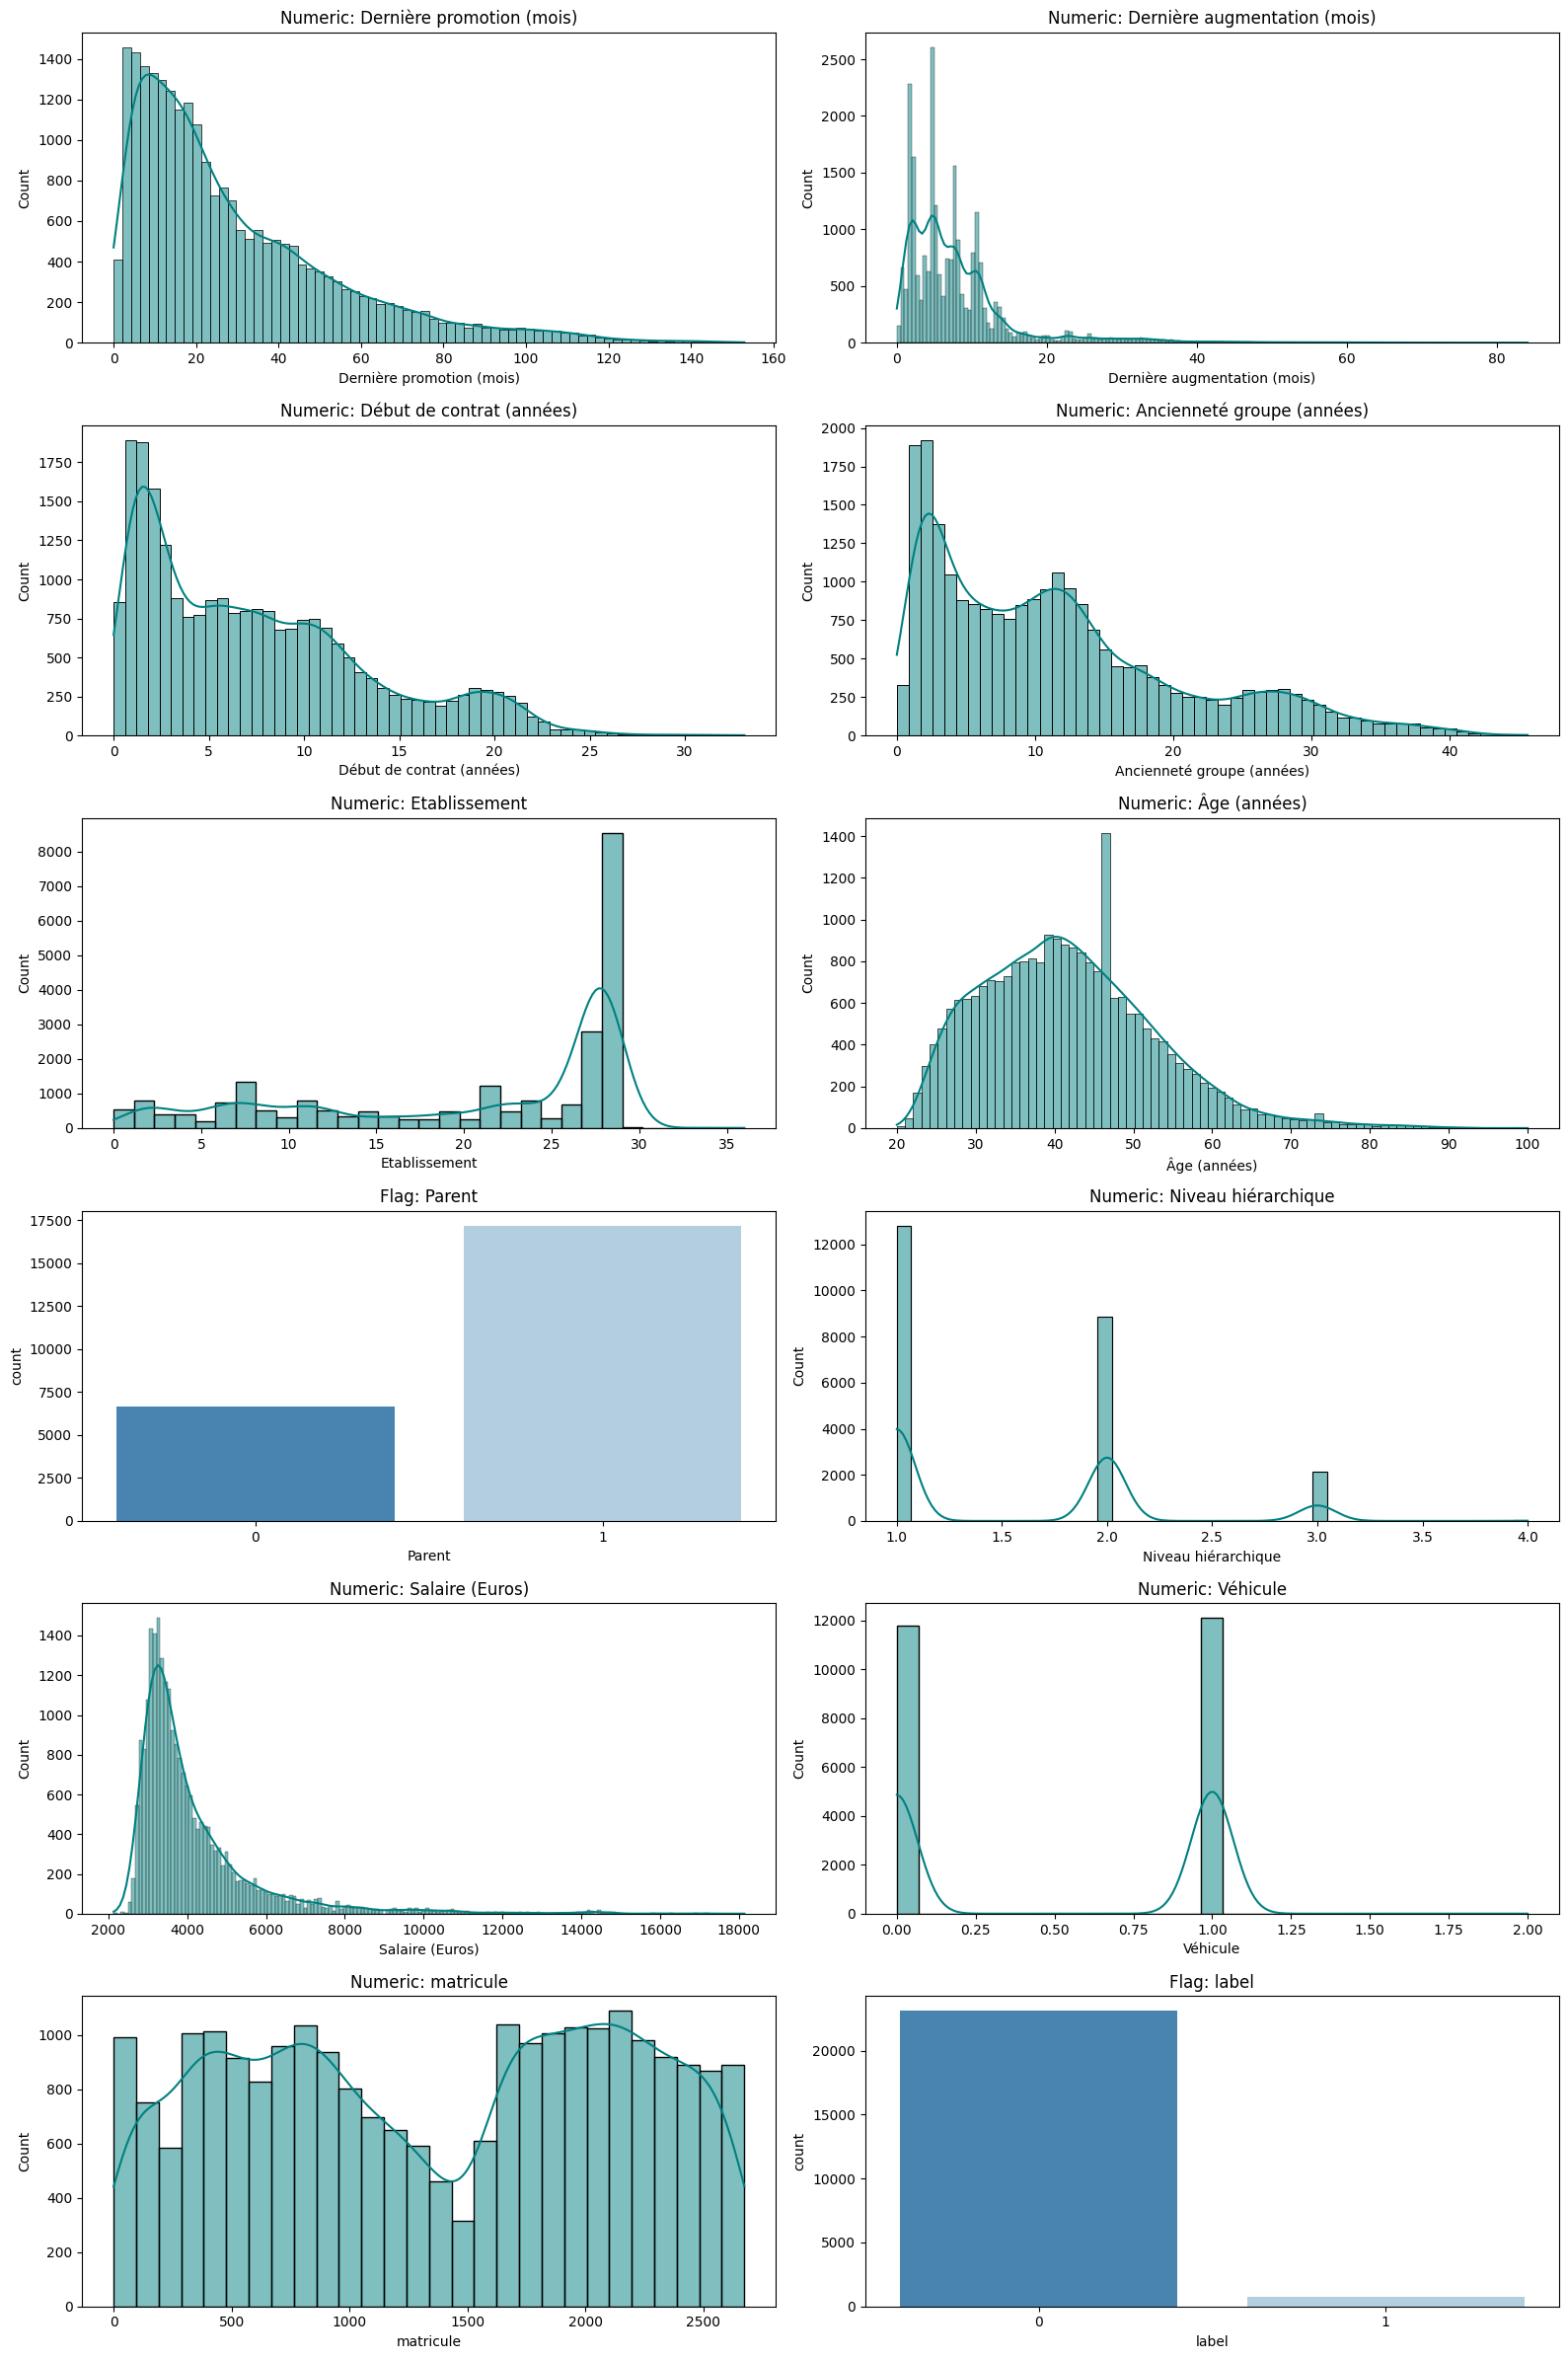

In [5]:
analysis_RH_raw.plot_distributions(['Dernière promotion (mois)',
       'Dernière augmentation (mois)', 'Début de contrat (années)',
       'Ancienneté groupe (années)', 'Etablissement', 'Âge (années)', 'Parent',
       'Niveau hiérarchique', 'Salaire (Euros)', 'Véhicule',
       'matricule', 'label'])

## Preprocessing sur les colonnes catégorielles

In [6]:
processed=DataPreprocessor(df).handle_encoding()

Encoding columns: ["Famille d'emploi", 'Statut marital']
Encoding complete. New shape: (23857, 29)


## Analyse du jeu de données - après preprocessing des colonnes catégorielles

In [7]:
analysis_RH=Analyzer(processed)
analysis_RH.df.columns

Dataset ready: 23857 rows and 29 columns.


Index(['Dernière_promotion_mois', 'Dernière_augmentation_mois',
       'Début_de_contrat_années', 'Ancienneté_groupe_années', 'Etablissement',
       'Âge_années', 'Parent', 'Niveau_hiérarchique', 'Salaire_Euros',
       'Véhicule', 'matricule', 'label', 'Famille_demploi_Commercial_Business',
       'Famille_demploi_Développement_Immobilier',
       'Famille_demploi_Etudes_&_Technique', 'Famille_demploi_IT',
       'Famille_demploi_Management', 'Famille_demploi_Matériel_Equipement',
       'Famille_demploi_Production', 'Famille_demploi_Support',
       'Statut_marital_Concubin', 'Statut_marital_Célibataire',
       'Statut_marital_Divorcée', 'Statut_marital_Mariée',
       'Statut_marital_PACS', 'Statut_marital_Séparée',
       'Statut_marital_Union_libre', 'Statut_marital_Veufve',
       'Statut_marital_ex_PACS'],
      dtype='object')

In [8]:
analysis_RH.get_inventory()

,Column,Type,Cardinality,Missing,Range/Examples
0,Dernière_promotion_mois,float64,7670,0,N/A (Numeric)
1,Dernière_augmentation_mois,float64,2934,0,N/A (Numeric)
2,Début_de_contrat_années,float64,2433,0,N/A (Numeric)
3,Ancienneté_groupe_années,float64,3660,0,N/A (Numeric)
4,Etablissement,int64,35,0,N/A (Numeric)
5,Âge_années,int64,74,0,N/A (Numeric)
6,Parent,int64,2,0,N/A (Numeric)
7,Niveau_hiérarchique,int64,4,0,N/A (Numeric)
8,Salaire_Euros,int64,4901,0,N/A (Numeric)
9,Véhicule,int64,3,0,N/A (Numeric)


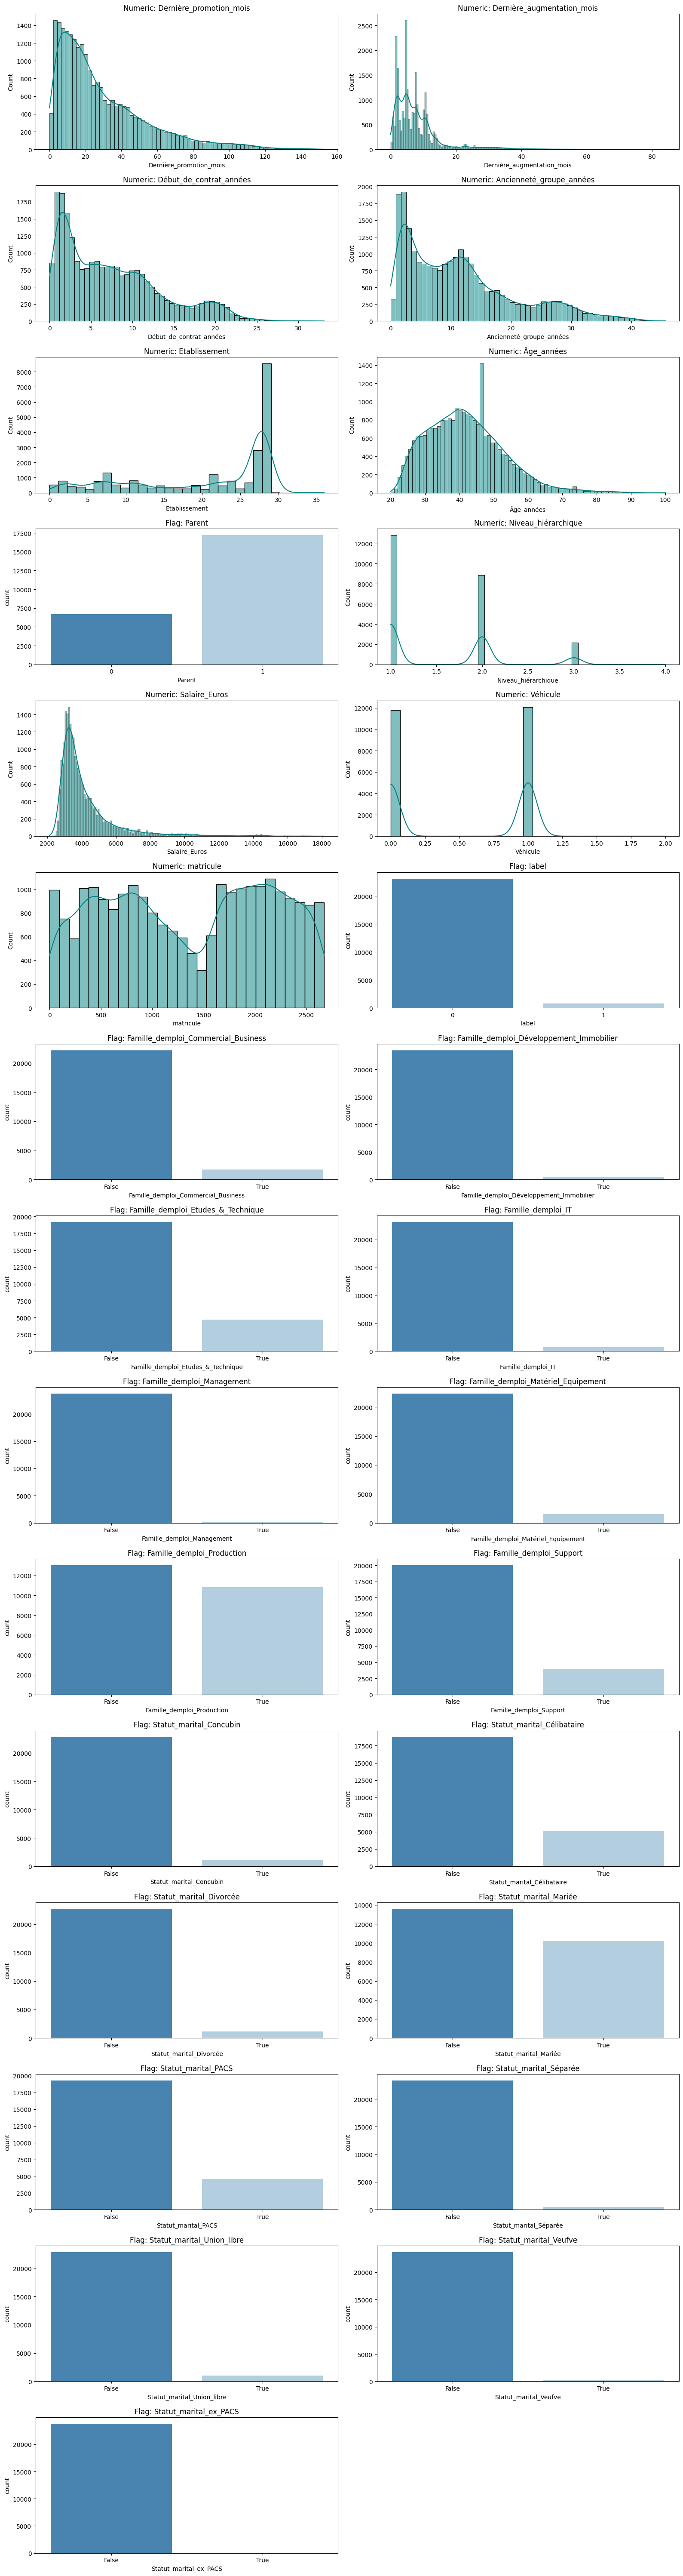

In [9]:
analysis_RH.plot_distributions(['Dernière_promotion_mois', 'Dernière_augmentation_mois',
       'Début_de_contrat_années', 'Ancienneté_groupe_années', 'Etablissement',
       'Âge_années', 'Parent', 'Niveau_hiérarchique', 'Salaire_Euros',
       'Véhicule', 'matricule', 'label', 'Famille_demploi_Commercial_Business',
       'Famille_demploi_Développement_Immobilier',
       'Famille_demploi_Etudes_&_Technique', 'Famille_demploi_IT',
       'Famille_demploi_Management', 'Famille_demploi_Matériel_Equipement',
       'Famille_demploi_Production', 'Famille_demploi_Support',
       'Statut_marital_Concubin', 'Statut_marital_Célibataire',
       'Statut_marital_Divorcée', 'Statut_marital_Mariée',
       'Statut_marital_PACS', 'Statut_marital_Séparée',
       'Statut_marital_Union_libre', 'Statut_marital_Veufve',
       'Statut_marital_ex_PACS'])

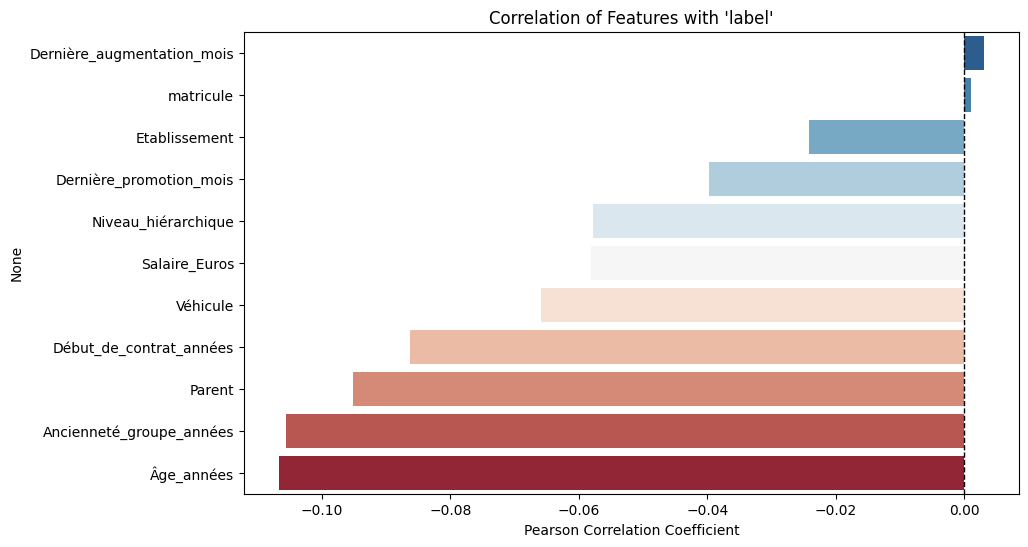

Dernière_augmentation_mois    0.003011
matricule                     0.001034
Etablissement                -0.024174
Dernière_promotion_mois      -0.039810
Niveau_hiérarchique          -0.057757
Salaire_Euros                -0.058090
Véhicule                     -0.065892
Début_de_contrat_années      -0.086285
Parent                       -0.095071
Ancienneté_groupe_années     -0.105627
Âge_années                   -0.106636
Name: label, dtype: float64

In [10]:
analysis_RH.target_correlation('label')

## Analyse des variables sensibles et biais potentiels